In [2]:
# importing
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4
from netCDF4 import Dataset
import math
from cartopy.util import add_cyclic_point
from sklearn import linear_model as lm
import statsmodels.formula.api as stm
import statsmodels.api as sm
from sklearn.metrics import r2_score
from numpy import genfromtxt
import rioxarray
from sklearn.linear_model import TheilSenRegressor
from scipy.ndimage import gaussian_filter1d
import requests
import itertools
from scipy.stats import linregress
import scipy.stats

from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import seaborn as sns
#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from rasterio import features
from affine import Affine
import geopandas as gp

plt.rcParams['hatch.linewidth'] = 1.5
plt.rcParams['hatch.color'] = 'k'
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.size'] = "16"
from matplotlib import rcParams
rcParams["mathtext.default"] = "regular"

import warnings
warnings.filterwarnings(action='ignore')

/dartfs-hpc/rc/home/q/f006fqq/.conda/envs/cl2025/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
#data dirs
grace_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GRACE/'
gini_dir = 'dartfs-hpc/rc/lab/C/CMIG/clesk/projects/plcl/data/hydro-gini/'
cpc_dir =  '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CPC/ppt/'
save_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/'
fig_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/'

In [4]:
def gini(x):
    # computes unweighted gini index on a vector
    # from: https://stackoverflow.com/questions/39512260/calculating-gini-coefficient-in-python-numpy
    # equivalent to (np.sum((2 * index - n  - 1) * x)) / (n * np.sum(x)), which is more common notation but slower
    
    n = len(x)
    
    # if obs missing, drop
    x[np.isnan(x)] = np.median(x)
    
    cumx = np.cumsum(x, dtype=float)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

In [5]:
pr_gini = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/CPC_daily_pr_gini_water_year_2002-2022.nc')


### adapted version of SEMBH model to output only dTWS

In [13]:
###################################################################################################################
###################################################################################################################
##### THIS IS THE SEBM FROM "THE PHYSICS OF HEAT WAVES" PAPER #####################################################
##### First function calculates saturation vapor pressure assuming constant surface pressure ######################
##### Second function accepts radiation and precipitation forcing and returns temperature and soil moisture #######
##### Extension by Lesk et al. : add surface water reservoir, so runoff doesn't disappear from model ##############
###################################################################################################################
###################################################################################################################


def q_s(TK): 					# ACCEPTS TEMPERAUTRE IN KELVIN
	T = TK - 273.15 			# Now in Celsius
	e_s = 6.11*10**(7.5*T/(237.5+T)) 	# Formula @ https://www.weather.gov/media/epz/wxcalc/vaporPressure.pdf
	q_s = 0.61*e_s/1013			# Converting to kg/kg
	return(q_s) # Given in units of kg H2O/ kg air

def the_model_Qint(pset):

	############# handle pset ##################################################
    
    # set perturbed params
    CN = pset[0]
    outflow_rate = pset[1]
    a_l = pset[2]
    h_l = pset[3]
    v_H = pset[4]
              
    # set a_s, which depends on a_l (sum to unity)
    a_s = 1-a_l
    
    # unpreturbed params
	############# Climatological constants #####################################

    q_clim = 0.005		# kg/kg 
    TD_clim = 280		# K
    DT = 86400			# in seconds (appropriate for daily forcing)

	########### Tunable parameters #################################################
    
    r_s = 150	# s/m
    r_lake = 50
    c = 12.8          # exponent relating saturated to unsaturated hydraulic conductivity
    Lambda = 0.05     # ratio of initial abstraction to potential maximum soil water retention       # curve number
    
############ Geometry

    h_s = 1			# surface layer depth [m]
    h_lake = h_l # surface reservoir depth [m]
    theta_max = 0.5		# porosity
    
############### Physical Constants
    
    ksat = 1e-4           # soil saturated hydraulic conductivity [mm/s]
    rho_l = 1000			# denisty of water [kg/m^3]
    rho_s = 1000			# density of dry soil [kg/m^3]
    rho_a = 1.25			# density of air [kg/m^3]
    c_ps  = 1000			# heat capacity of dry soil [J/kg/K]
    L = 2257000			# Latent enthalpy of vaporization [J/kg]
   
    
################### Combined parameters

    mu_s = rho_l*h_s*theta_max	# storage capacity of surface layer [kg/m^2]
    C_s = rho_s*h_s*c_ps		# effective heat capacity of land surface [J/m^2/K]
    S = 25.4*(1000/CN - 10)       # potential max soil water retention (mm -- trans
    I = Lambda*S             # initial abstraction

    ### set forcings for low gini:
    
########### F forcing is W/m^2
########### P forcing is in mm per unit of time
    F_forcing = sw_forcing
    P_forcing = p_forcing
    
################# State Variables
    N = len(F_forcing)
    #T = np.zeros(N)
    #m_s = np.zeros(N)
    #m_d = np.zeros(N)
    #lake = np.zeros(N)
    #LHF = np.zeros(N)
    #ET_lake = np.zeros(N)
    #ET_land = np.zeros(N)
    #Qtotal = np.zeros(N)
    #Qoutl = np.zeros(N)
    
    TWS = 0
    
    T = 280			# Initial condition for surface temperature
    m_s = 0.5			# ""			surface moisture
    lake = 0.5
    
    i = 0
    while i < N-1:
		
        ######### time dependend paramters ###############################
        k = ksat*m_s**c
        
		######### CALCULATING FLUXES #####################################
			
        H = v_H*(T - TD_clim)		# Sensible Heat Flux [W/m^2]
        VPD = q_s(T) - q_clim		# Vapor Pressure Deficit [kPa]

        ET = rho_a*m_s*VPD/r_s	# Surface Evaporation [kg/m^2/s]
        ETlake = rho_a*lake*VPD/r_lake
        #else:
        #    ET = 0
        #    ETlake = 0

        ET_land = DT*ET
        ET_lake = DT*ETlake
        LHF = L*ET  #(a_s*ET+a_l*ETlake) ###

        #drainage
        Qdrain = k #mm/s
            
        #surface runoff
        if (P_forcing[i] > I).any():
            Qinfl = (P_forcing[i]-I)**2 / (P_forcing[i]-I+S) #mm/d
        else:
            Qinfl = 0
        
        #precip - infiltration excess
        Pnet = P_forcing[i] - Qinfl
        
        #lake outflow
       # if lake[i] > 0.5:
        Qout = outflow_rate*lake**2
       # else:
       #     Qout = 0
            
        # saturation excess runoff
       # Qsat = 0 # unless m_s > 1, below
        
		########## TENDENCY EQUATIONS #####################################

        dT_dt = (F_forcing[i] - H - LHF)/C_s
        dms_dt = -((ET + Qdrain)/mu_s)        
        
		############# INTEGRATING FORWARD IN TIME #########################
        T	= T + dT_dt*DT
        m_s	= m_s + dms_dt*DT + Pnet/mu_s #corrected P term units
        
		############# SATURATION CONSTRAINTS #######
        #m_s = min(m_s,1)
        #m_s = max(m_s,0)
        
        ############ FINALLY, INTEGRATE SURFACE RESERVOIR ############
        dl_dt = (Qdrain*DT + Qinfl)*a_s / (a_l * rho_l * h_lake)
        lake = lake + dl_dt + P_forcing[i]/(rho_l*h_lake) - Qout - ETlake*DT/(rho_l * h_lake)
   
        TWS += 1000/N*(params['h_s']*params['a_s']*params['theta_max']*m_s + params['h_l']*params['a_l']*lake)
        i+=1



    ### set forcings for low gini:
########### F forcing is W/m^2
########### P forcing is in mm per unit of time
    F_forcing = sw_int
    P_forcing = p_int
    
################# State Variables
    N = len(F_forcing)
    #T = np.zeros(N)
    #m_s = np.zeros(N)
    #m_d = np.zeros(N)
    #lake = np.zeros(N)
    #LHF = np.zeros(N)
    #ET_lake = np.zeros(N)
    #ET_land = np.zeros(N)
    #Qtotal = np.zeros(N)
    #Qoutl = np.zeros(N)
    TWS_int = 0
    
    T = 280			# Initial condition for surface temperature
    m_s = 0.5			# ""			surface moisture
    lake = 0.5
    
    i = 0
    while i < N-1:
		
        ######### time dependend paramters ###############################
        k = ksat*m_s**c
        
		######### CALCULATING FLUXES #####################################
			
        H = v_H*(T - TD_clim)		# Sensible Heat Flux [W/m^2]
        VPD = q_s(T) - q_clim		# Vapor Pressure Deficit [kPa]

        #if VPD > 0 and T > 273.15:
        ET = rho_a*m_s*VPD/r_s	# Surface Evaporation [kg/m^2/s]
        ETlake = rho_a*lake*VPD/r_lake
        #else:
        #    ET = 0
        #    ETlake = 0

        ET_land = DT*ET
        ET_lake = DT*ETlake
        LHF = L*ET  #(a_s*ET+a_l*ETlake) ###

        #drainage
        Qdrain = k #mm/s
            
        #surface runoff
        if (P_forcing[i] > I).any():
            Qinfl = (P_forcing[i]-I)**2 / (P_forcing[i]-I+S) #mm/d
        else:
            Qinfl = 0
        
        #precip - infiltration excess
        Pnet = P_forcing[i] - Qinfl
        
        #lake outflow
       # if lake[i] > 0.5:
        Qout = outflow_rate*lake**2
       # else:
       #     Qout = 0
            
        # saturation excess runoff
       # Qsat = 0 # unless m_s > 1, below
        
		########## TENDENCY EQUATIONS #####################################

        dT_dt = (F_forcing[i] - H - LHF)/C_s
        dms_dt = -((ET + Qdrain)/mu_s)        
        
		############# INTEGRATING FORWARD IN TIME #########################
        T	= T + dT_dt*DT
        m_s	= m_s + dms_dt*DT + Pnet/mu_s #corrected P term units
        
		############# SATURATION CONSTRAINTS #######

        #if m_s > 1:
            #Qsat = (m_s[i+1]-1)*mu_s
        #    m_s = 1
            
        #elif m_s < 0:
        #    m_s = 0
        
        ############ FINALLY, INTEGRATE SURFACE RESERVOIR ############
        dl_dt = (Qdrain*DT + Qinfl)*a_s / (a_l * rho_l * h_lake)
        lake = lake + dl_dt + P_forcing[i]/(rho_l*h_lake) - Qout - ETlake*DT/(rho_l * h_lake)
        
        TWS_int += 1000/N*(h_s*a_s*theta_max*m_s + h_l*a_l*lake)#/(params['a_l']+params['a_s'])

        i+=1


################# compute and return dTWS
    dTWS = TWS_int-TWS
    return dTWS
#################


In [14]:
# get forcings for hi/low gp years at a given point

def hiLoGpForcing(lon,lat):
    
    #convert point for native CPC resolution
    #lnc = np.floor(s[1])+0.5
    #ltc = np.floor(s[0])+0.5
    
    #get max and min Gp years
    gpsub = pr_gini_wy.sel(lon=lon,lat=lat,water_year=np.arange(2002,2017))
  
    min_year = gpsub['water_year'].isel(water_year=gpsub['Pgini_wy'].argmin(dim='water_year')).values
    max_year = gpsub['water_year'].isel(water_year=gpsub['Pgini_wy'].argmax(dim='water_year')).values
    
    #select P forcings for those years
    p_forcing = cpc_rs.sel(time=slice(f'{min_year-1}-10-01', f'{min_year}-09-30'),lon=lon,lat=lat).precip.compute().values
    p_int = cpc_rs.sel(time=slice(f'{max_year-1}-10-01', f'{max_year}-09-30'),lon=lon,lat=lat).precip

    # ratio of total precip, hi:lo Gp years
    dP = p_int.sum()/p_forcing.sum()

    #scale more intense year to have same total precip
    p_int = (p_int/dP).compute().values

    #select sw forcings
    sw_forcing = sw.sel(time=slice(f'{min_year-1}-10-01', f'{min_year}-09-30'),lon=lon,lat=lat).compute().values
    sw_int = sw.sel(time=slice(f'{max_year-1}-10-01', f'{max_year}-09-30'),lon=lon,lat=lat).compute().values
    
    # difference in dry days and shortwave (just for interpretation)
    dN = sum(p_int<0.1) - sum(p_forcing<0.1)
    dSW = sw_int.mean() - sw_forcing.mean()
    
    return p_forcing,p_int,sw_forcing,sw_int,dN,dSW,min_year,max_year


In [120]:
# using forcing timeseries hi/lo Gp defined outside wrapper, takes perturbed parameters, runs model for each, calculates dTWS
def calcdTWS(pset):
    

    # reset default
    params = default_params()
    
    # set perturbed params
    params['CN'] = pset[0]
    params['outflow_rate'] = pset[1]
    params['a_l'] = pset[2]
    params['h_l'] = pset[3]
    params['v_H'] = pset[4]
              
    # set a_s, which depends on a_l (sum to unity)
    params['a_s'] = 1-params['a_l']
    
    # run model
    SM,L = the_model_Q(params)
    
    P_forcing = p_int
    F_forcing = sw_int
    SM_int,L_int = the_model_Qint(params)
    TWS = calcTWS(SM,L,params)
    TWS_int = calcTWS(SM_int,L_int,params)
    dTWS = (np.mean(TWS_int)-np.mean(TWS))
    
    return np.array(dTWS)

In [7]:
# input forcing data
cpc = xr.open_mfdataset(cpc_dir + '*.nc')

#load SRB and select surface all-sky downwelling shortwave
srb_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/GEWEX-SRB/'
srb_ds = xr.open_mfdataset(srb_dir + 'GEWEXSRB_Rel4-IP_Shortwave_daily_local*.nc4')
sw = srb_ds.all_sw_dn_sfc

#resample CPC to SRB resolution
cpc_rs = cpc.interp_like(sw.sel(time=sw.time[0]))
pr_gini_wy = pr_gini.interp_like(sw.sel(time=sw.time[0]))

In [8]:
# default and perturbed params
def default_params():

    params = {# geometry
              'a_s':0.9,
              'a_l':0.1,
              'h_s':1,
              'h_l':10,
              'theta_max':0.5,

              # climatology
              'q_clim':0.005,
              'TD_clim':280,

              # initial conditions
              'm_s0':0.5,
              'm_l0':0.5,

              # tunable parameters
              'r_s':150,			# s/m
              'r_l':50,
              'v_H':10,			# W/m^2/K
              'ks':1e-4,
              'outflow_rate':0.005, #fraction per day
              'c':12.8,          # exponent relating saturated to unsaturated hydraulic conductivity
              'Lambda':0.05,     # ratio of initial abstraction to potential maximum soil water retention
              'CN':80       # curve number
             }

    return params


params_space = {'CN': [30,50,80],
                'outflow_rate': [0.001,0.005,0.01],
                'a_l':  [0.01,0.1,0.25],
                'h_l': [1,5,10],
                'v_H': [8,10,12]
                #'Lambda': [0.05,0.1,0.2],
                #'ks_range': [10**-n for n in range(3,6)]
               }

In [9]:
# setup param space distribution objects for GVBSA
param_names = list(params_space.keys())
pdists = []

for pn in param_names:
    paramin = min(params_space[pn])
    paramax = max(params_space[pn])
    pdists.append(scipy.stats.uniform(loc=paramin,scale=paramax-paramin))


In [10]:

#get forcings
lon = 280.5
lat = 37.5
p_forcing,p_int,sw_forcing,sw_int = hiLoGpForcing(lon,lat)

#test new wrapper function with median params
pset = [80,0.005,0.1,10,10]
params = default_params()

the_model_Qint(pset)




ValueError: too many values to unpack (expected 4)

In [19]:
# with model wrapped in calcdTWS, can run GVBSA
indices = scipy.stats.sobol_indices(func=the_model_Qint, n=2048,dists=pdists)
    

In [17]:
indices.total_order

array([0.00191775, 0.02048305, 0.64391855, 0.3882427 , 0.00221785])

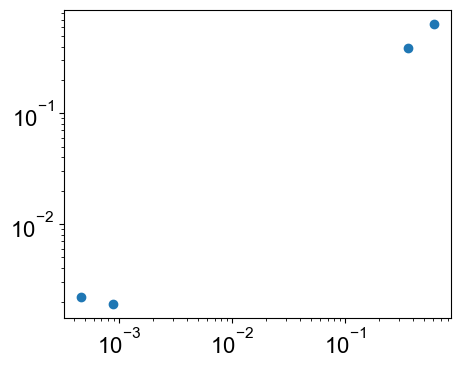

In [18]:
fig,ax = plt.subplots(figsize=(5,4))
ax.scatter(indices.first_order,indices.total_order)
ax.set_yscale('log')
ax.set_xscale('log')

### sample space and repeat sobol

In [11]:
pexq_df = pd.read_csv(save_dir+'pexq_df.csv')


In [15]:
params = default_params()
n = 10

# mean p range
pincr = 200
prange = np.arange(0,3200,pincr)
rdict_first = {}
rdict_total = {}

for psamp in prange:
    print(psamp)
    
    #desert parameter set?
    if psamp <= 200:
        params_set = params
    else:
        params_set = params

    #select all points in this mean p range
    dfsub = pexq_df[(pexq_df['Pmean'] >= psamp) & (pexq_df['Pmean'] <= psamp+pincr)]
    dfsub = dfsub[['gridindex', 'Pmean']].drop_duplicates().reset_index(drop=True)
    
    # random sample from those points
    sample_ids = np.random.choice(dfsub['gridindex'], n, replace=False)
    sample = [[float(s.split('_')[0]),float(s.split('_')[1])] for s in sample_ids]
    
    # results storage
    firstdf = pd.DataFrame(columns=['CN','outflow_rate','a_l','h_l','v_H'])
    totaldf = pd.DataFrame(columns=['CN','outflow_rate','a_l','h_l','v_H'])
                                     
    for i,s in enumerate(sample):
        if i%10 == 0: print(i)
        
        lon = np.floor(s[1])+0.5
        lat = np.floor(s[0])+0.5
        pmean = dfsub[dfsub.gridindex == sample_ids[i]].Pmean.values[0]
        
        #prep forcings
        try:
            p_forcing,p_int,sw_forcing,sw_int,dN,dSW,minyr,maxyr = hiLoGpForcing(lon,lat)
        except:
            print('forcing load error')
            continue
            
        #model runs
        indices = scipy.stats.sobol_indices(func=the_model_Qint, n=1024,dists=pdists)

        # populate df
        firstdf.loc[i] = list(indices.first_order)
        totaldf.loc[i] = list(indices.total_order)
    
    rdict_first[str(psamp)] = firstdf
    rdict_total[str(psamp)] = totaldf


0
0
200
0
400
0
600
0
forcing load error
800
0
1000
0
forcing load error
1200
0
forcing load error
1400
0
1600
0
1800
0
forcing load error
2000
0
2200
0
forcing load error
2400
0
forcing load error
forcing load error
2600
0
forcing load error
forcing load error
forcing load error
2800
0
forcing load error
forcing load error
forcing load error
3000
0
forcing load error
forcing load error


In [16]:
rdf_first = pd.concat(
    rdict_first, 
    names=['Key']
).reset_index(level='Key').reset_index(drop=True)

rdf_total = pd.concat(
    rdict_total, 
    names=['Key']
).reset_index(level='Key').reset_index(drop=True)

In [17]:
rdf_first.to_csv(save_dir+'GVBSA_indices_first_order_N10.csv')
rdf_total.to_csv(save_dir+'GVBSA_indices_total_order_N10.csv')

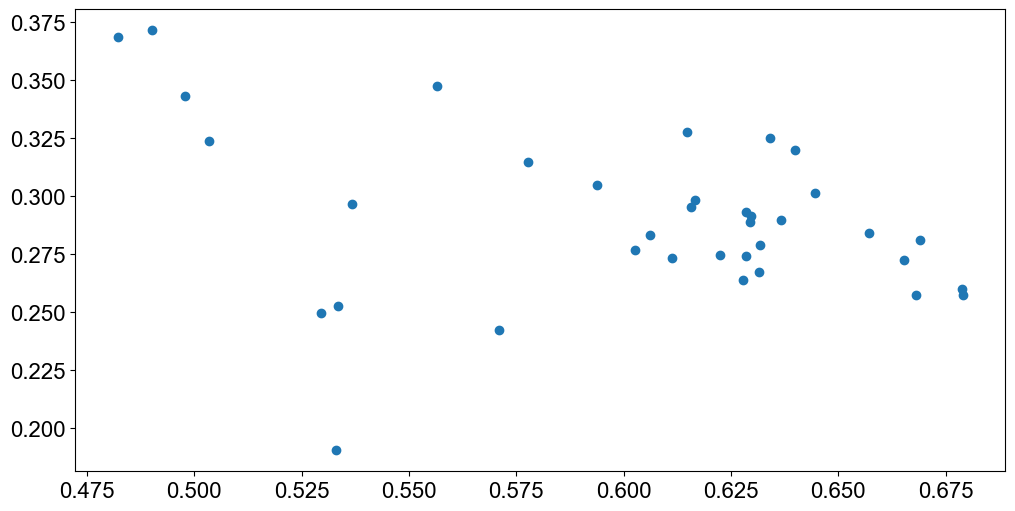

In [55]:
plt.scatter(rdf_first.a_l,rdf_first.h_l)

In [24]:
rdf_first.to_csv(save_dir+'GVBSA_indices_first_order_N10.csv')
rdf_total.to_csv(save_dir+'GVBSA_indices_total_order_N10.csv')

['CN', 'outflow_rate', 'a_l', 'h_l', 'v_H']

0.5635113932109335
0.28754646382811094
0.0008006096387922961
0.0008022458771243135
0.007685155194400636
0.5635113932109335
0.28754646382811094
0.0008006096387922961
0.0008022458771243135
0.007685155194400636


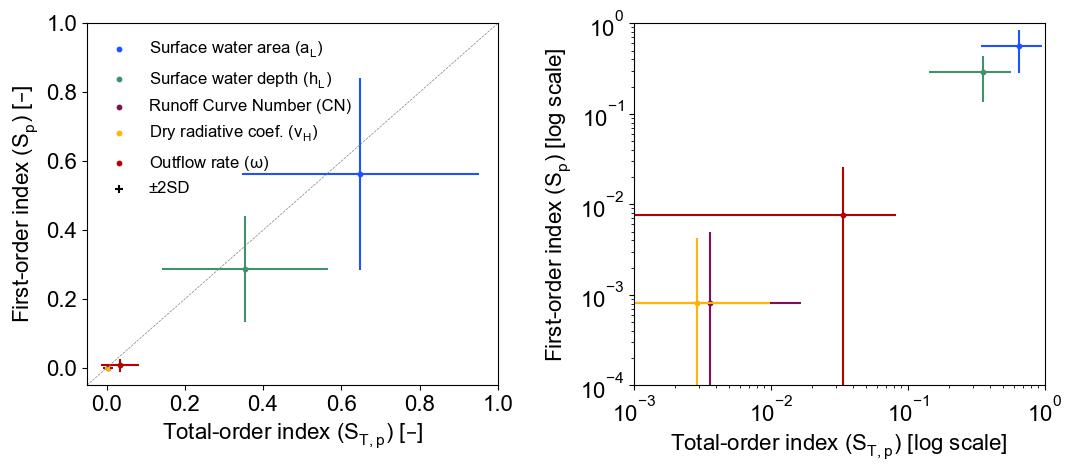

In [30]:
fig,axs = plt.subplots(1,2,figsize=(11,5))

prms = list(rdf_first.columns[1:])
colors = ['#1a53ff',  '#40916c', '#7c1158',  '#ffb501','#b30000']
labs = ['Surface water area ($a_L$)','Surface water depth ($h_L$)','Runoff Curve Number (CN)',
        'Dry radiative coef. ($v_H$)','Outflow rate ($\omega$)','±2SD']

prms = ['a_l','h_l','CN','v_H','outflow_rate']

for ax in axs:
    pts = []
    
    for i,prm in enumerate(prms):
        print(rdf_first[prm].mean())
        
        pt=ax.scatter(rdf_total[prm].mean(),rdf_first[prm].mean(),c=colors[i],s=10)
        ax.errorbar(rdf_total[prm].mean(),rdf_first[prm].mean(),
                    xerr=2*rdf_total[prm].std(),
                    yerr=2*rdf_first[prm].std(),
                    c=colors[i])
        pts.append(pt)

    

    
    if ax == axs[0]:
        ax.set_ylabel('First-order index ($S_p$) [–]')
        ax.set_xlabel('Total-order index ($S_{T,p}$) [–]')
        l=ax.scatter([],[],marker='+',color='k')
        ax.legend(pts+[l],labs,fontsize=12,frameon=False)
        ax.set_ylim(-0.05,1)
        ax.set_xlim(-0.05,1)
        ax.plot([-0.05,1],[-.05,1],linestyle='--',color='grey',linewidth=0.5)
        
    if ax == axs[1]:
        ax.set_ylabel('First-order index ($S_p$) [log scale]')
        ax.set_xlabel('Total-order index ($S_{T,p}$) [log scale]')
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_ylim([1e-4,1])
        ax.set_xlim([1e-3,1])


plt.tight_layout()

### checking parameter distributions

Text(0.5, 1.0, 'v_H')

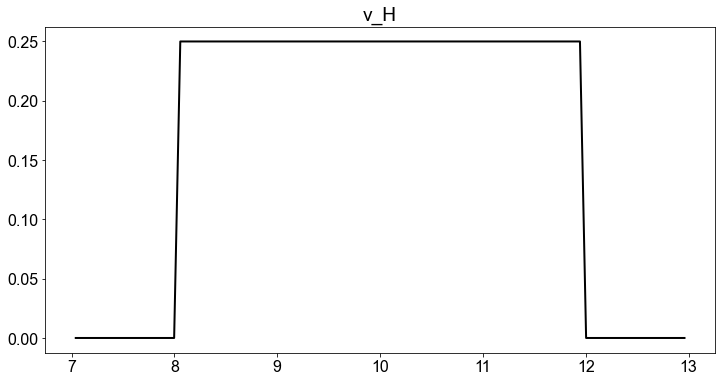

In [125]:
ind = 4
paramin = min(params_space[param_names[ind]])
paramax = max(params_space[param_names[ind]])
dist =  scipy.stats.uniform(loc=paramin,scale=paramax-paramin)
x = np.linspace(dist.ppf(0.01)-1,dist.ppf(0.99)+1, 100)
plt.plot(x,dist.pdf(x),'k-', lw=2, label='frozen pdf')
plt.title(param_names[ind])

2.0000000000000013